# Notebook 5 ? Preprocessing and Model Selection

## Purpose

Build a reproducible machine-learning preprocessing and modelling pipeline for late-delivery prediction.

## Data usage

- **Training split:** fit preprocessing and models.
- **Validation split:** compare models and choose a decision threshold.
- **Test split:** remains untouched until Notebook 6.

## Prediction point

The model predicts late-delivery risk after order/payment approval but before carrier handoff and final delivery.

Only information available by that point is allowed as a predictor.

## Evaluation

Because late orders are a minority class, accuracy alone is not sufficient.

We compare:

- precision;
- recall;
- F1 score;
- ROC-AUC;
- average precision / PR-AUC.

PR-AUC is used as the primary model-selection metric.


## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

print(f"scikit-learn version: {sklearn.__version__}")
print("Imports completed successfully.")

scikit-learn version: 1.9.0
Imports completed successfully.


## 2. Resolve artifacts

Training and validation are opened.

The test file is deliberately not loaded.


In [2]:
WORKING_DIR = Path.cwd().resolve()
PROJECT_ROOT = WORKING_DIR.parent if WORKING_DIR.name == "notebooks" else WORKING_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_PATH = PROCESSED_DIR / "train.parquet"
VALIDATION_PATH = PROCESSED_DIR / "validation.parquet"
TEST_PATH = PROCESSED_DIR / "test.parquet"

assert TRAIN_PATH.exists()
assert VALIDATION_PATH.exists()
assert TEST_PATH.exists()

train = pd.read_parquet(TRAIN_PATH)
validation = pd.read_parquet(VALIDATION_PATH)

print(f"Training shape: {train.shape}")
print(f"Validation shape: {validation.shape}")
print(f"Training late rate: {train['is_late'].mean():.4%}")
print(f"Validation late rate: {validation['is_late'].mean():.4%}")
print("Test data opened: NO")

Training shape: (67529, 67)
Validation shape: (14470, 67)
Training late rate: 7.8337%
Validation late rate: 4.3124%
Test data opened: NO


## 3. Explicit prediction-time feature contract

We use a whitelist rather than automatically using every available column.

This prevents identifiers, delivery outcomes, reviews, and other post-delivery information from accidentally entering the model.


In [3]:
BASE_NUMERIC_FEATURES = [
    "item_count",
    "unique_product_count",
    "unique_seller_count",
    "item_price_total",
    "item_price_mean",
    "item_price_max",
    "freight_value_total",
    "freight_value_mean",
    "unique_product_category_count",
    "product_name_length_mean",
    "product_description_length_mean",
    "product_photos_qty_mean",
    "product_weight_g_total",
    "product_weight_g_mean",
    "product_length_cm_mean",
    "product_height_cm_mean",
    "product_width_cm_mean",
    "primary_category_item_count",
    "unique_seller_city_count",
    "unique_seller_state_count",
    "primary_seller_item_count",
    "payment_record_count",
    "unique_payment_type_count",
    "payment_value_total",
    "payment_value_mean",
    "payment_installments_max",
    "payment_installments_mean",
    "primary_payment_type_value",
    "primary_payment_type_record_count",
    "customer_lat_median",
    "customer_lng_median",
    "customer_geolocation_record_count",
    "primary_seller_lat_median",
    "primary_seller_lng_median",
    "primary_seller_geolocation_record_count",
]

BASE_CATEGORICAL_FEATURES = [
    "customer_record_found",
    "customer_state",
    "primary_seller_state",
    "primary_product_category",
    "primary_payment_type",
]

TIME_SOURCE_COLUMNS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "shipping_limit_date_min",
    "shipping_limit_date_max",
]

FORBIDDEN_COLUMNS = {
    "order_id",
    "customer_id",
    "customer_unique_id",
    "primary_seller_id",
    "order_status",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "delivery_delay_days",
    "post_delivery_review_count",
    "post_delivery_review_score_mean",
    "post_delivery_review_score_min",
    "post_delivery_review_score_max",
    "post_delivery_review_title_count",
    "post_delivery_review_message_count",
    "post_delivery_review_message_length_mean",
    "post_delivery_review_creation_date_min",
    "post_delivery_review_answer_timestamp_max",
    "is_late",
}

required_raw_columns = (
    set(BASE_NUMERIC_FEATURES)
    | set(BASE_CATEGORICAL_FEATURES)
    | set(TIME_SOURCE_COLUMNS)
    | {"is_late"}
)

for split_name, frame in {
    "train": train,
    "validation": validation,
}.items():
    missing = sorted(required_raw_columns - set(frame.columns))
    assert not missing, f"{split_name} is missing columns: {missing}"

used_raw_predictors = (
    set(BASE_NUMERIC_FEATURES)
    | set(BASE_CATEGORICAL_FEATURES)
    | set(TIME_SOURCE_COLUMNS)
)

assert not (used_raw_predictors & FORBIDDEN_COLUMNS)

print(f"Base numeric features: {len(BASE_NUMERIC_FEATURES)}")
print(f"Base categorical features: {len(BASE_CATEGORICAL_FEATURES)}")
print(f"Timestamp sources: {len(TIME_SOURCE_COLUMNS)}")
print("Forbidden feature overlap: 0")
print("Leakage contract passed.")

Base numeric features: 35
Base categorical features: 5
Timestamp sources: 5
Forbidden feature overlap: 0
Leakage contract passed.


## 4. Prediction-time feature engineering

Timestamp fields are converted into useful durations/calendar features.

We also calculate approximate customer-to-primary-seller geographic distance.


In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(pd.to_numeric(lat1, errors="coerce"))
    lon1 = np.radians(pd.to_numeric(lon1, errors="coerce"))
    lat2 = np.radians(pd.to_numeric(lat2, errors="coerce"))
    lon2 = np.radians(pd.to_numeric(lon2, errors="coerce"))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))


def build_prediction_features(frame):
    X = frame[
        BASE_NUMERIC_FEATURES + BASE_CATEGORICAL_FEATURES
    ].copy()

    for column in BASE_NUMERIC_FEATURES:
        X[column] = pd.to_numeric(X[column], errors="coerce")

    for column in BASE_CATEGORICAL_FEATURES:
        X[column] = X[column].astype("object")
        X.loc[X[column].isna(), column] = np.nan

    purchase = pd.to_datetime(
        frame["order_purchase_timestamp"],
        errors="coerce",
    )

    approved = pd.to_datetime(
        frame["order_approved_at"],
        errors="coerce",
    )

    estimated = pd.to_datetime(
        frame["order_estimated_delivery_date"],
        errors="coerce",
    )

    shipping_min = pd.to_datetime(
        frame["shipping_limit_date_min"],
        errors="coerce",
    )

    shipping_max = pd.to_datetime(
        frame["shipping_limit_date_max"],
        errors="coerce",
    )

    X["approval_delay_hours"] = (
        approved - purchase
    ).dt.total_seconds() / 3600

    X["estimated_delivery_window_days"] = (
        estimated - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_min_days"] = (
        shipping_min - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_max_days"] = (
        shipping_max - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_span_days"] = (
        shipping_max - shipping_min
    ).dt.total_seconds() / 86400

    X["purchase_month"] = purchase.dt.month.astype("float64")
    X["purchase_day_of_week"] = purchase.dt.dayofweek.astype("float64")
    X["purchase_hour"] = purchase.dt.hour.astype("float64")

    X["customer_seller_distance_km"] = haversine_km(
        frame["customer_lat_median"],
        frame["customer_lng_median"],
        frame["primary_seller_lat_median"],
        frame["primary_seller_lng_median"],
    )

    X["freight_to_price_ratio"] = (
        pd.to_numeric(frame["freight_value_total"], errors="coerce")
        / pd.to_numeric(frame["item_price_total"], errors="coerce").replace(0, np.nan)
    )

    same_state = frame["customer_state"].eq(
        frame["primary_seller_state"]
    )

    missing_state = (
        frame[["customer_state", "primary_seller_state"]]
        .isna()
        .any(axis=1)
    )

    X["customer_seller_same_state"] = (
        same_state.mask(missing_state, np.nan).astype(float)
    )

    return X


X_train = build_prediction_features(train)
X_validation = build_prediction_features(validation)

y_train = train["is_late"].astype(int)
y_validation = validation["is_late"].astype(int)

assert list(X_train.columns) == list(X_validation.columns)
assert len(X_train) == len(y_train)
assert len(X_validation) == len(y_validation)

print(f"Final predictor columns: {X_train.shape[1]}")
print(f"Training rows: {len(X_train):,}")
print(f"Validation rows: {len(X_validation):,}")
print("Feature engineering completed successfully.")

Final predictor columns: 51
Training rows: 67,529
Validation rows: 14,470
Feature engineering completed successfully.


## 5. Preprocessing pipeline

Numerical features:

- median imputation;
- standardization.

Categorical features:

- most-frequent imputation;
- one-hot encoding;
- rare categories grouped using `min_frequency=20`.

All preprocessing is fitted on training data only.


In [5]:
derived_numeric_features = [
    column
    for column in X_train.columns
    if column not in BASE_CATEGORICAL_FEATURES
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            derived_numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            BASE_CATEGORICAL_FEATURES,
        ),
    ]
)

print(f"Numeric model features: {len(derived_numeric_features)}")
print(f"Categorical model features: {len(BASE_CATEGORICAL_FEATURES)}")
print("Preprocessor defined.")

Numeric model features: 46
Categorical model features: 5
Preprocessor defined.


## 6. Candidate models

Three models are compared:

1. Dummy classifier ? establishes the no-skill baseline.
2. Balanced logistic regression ? interpretable linear classifier.
3. Balanced random forest ? nonlinear tree ensemble.

All models use the same train-only fitted preprocessing contract.


In [6]:
models = {
    "dummy_prior": DummyClassifier(
        strategy="prior",
    ),
    "logistic_balanced": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "random_forest_balanced": RandomForestClassifier(
        n_estimators=200,
        max_depth=16,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

print("Candidate models:")
for name in models:
    print(f"- {name}")

Candidate models:
- dummy_prior
- logistic_balanced
- random_forest_balanced


## 7. Train and evaluate on validation data

The validation set is used for model selection.

The test set remains unopened.


In [7]:
fitted_models = {}
evaluation_records = []

for model_name, estimator in models.items():
    print(f"Training: {model_name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    pipeline.fit(X_train, y_train)

    validation_prediction = pipeline.predict(X_validation)
    validation_probability = pipeline.predict_proba(X_validation)[:, 1]

    evaluation_records.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(
                y_validation,
                validation_prediction,
            ),
            "precision": precision_score(
                y_validation,
                validation_prediction,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                validation_prediction,
                zero_division=0,
            ),
            "f1": f1_score(
                y_validation,
                validation_prediction,
                zero_division=0,
            ),
            "roc_auc": roc_auc_score(
                y_validation,
                validation_probability,
            ),
            "average_precision": average_precision_score(
                y_validation,
                validation_probability,
            ),
        }
    )

    fitted_models[model_name] = pipeline

model_results = (
    pd.DataFrame(evaluation_records)
    .sort_values(
        ["average_precision", "roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    model_results.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "average_precision": "{:.4f}",
        }
    )
)

print("Model training and validation completed.")
print("Test data opened: NO")

Training: dummy_prior


Training: logistic_balanced


Training: random_forest_balanced


,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,logistic_balanced,0.7059,0.0979,0.7083,0.1720,0.7743,0.1333
1,random_forest_balanced,0.9328,0.1420,0.1106,0.1243,0.6989,0.0982
2,dummy_prior,0.9569,0.0000,0.0000,0.0000,0.5000,0.0431


Model training and validation completed.
Test data opened: NO


## 8. Model comparison

Average precision / PR-AUC is emphasized because the positive class is relatively rare.


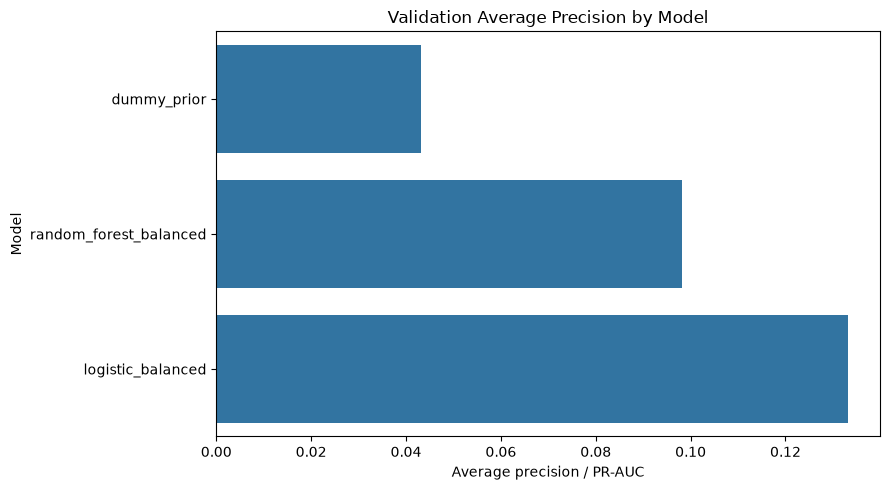

Best validation model: logistic_balanced
Best validation average precision: 0.1333
Best validation ROC-AUC: 0.7743


In [8]:
plt.figure(figsize=(9, 5))

plot_results = model_results.sort_values(
    "average_precision",
    ascending=True,
)

sns.barplot(
    data=plot_results,
    x="average_precision",
    y="model",
)

plt.title("Validation Average Precision by Model")
plt.xlabel("Average precision / PR-AUC")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

best_model_name = model_results.iloc[0]["model"]
best_pipeline = fitted_models[best_model_name]

print(f"Best validation model: {best_model_name}")
print(
    "Best validation average precision: "
    f"{model_results.iloc[0]['average_precision']:.4f}"
)
print(
    "Best validation ROC-AUC: "
    f"{model_results.iloc[0]['roc_auc']:.4f}"
)

## 9. Validation threshold selection

A probability threshold of 0.50 is not automatically optimal for an imbalanced problem.

We select the threshold that maximizes validation F1.

This threshold will be frozen before the final test evaluation.


In [9]:
validation_probability = best_pipeline.predict_proba(
    X_validation
)[:, 1]

precision_values, recall_values, thresholds = precision_recall_curve(
    y_validation,
    validation_probability,
)

if len(thresholds) > 0:
    numerator = (
        2
        * precision_values[:-1]
        * recall_values[:-1]
    )

    denominator = (
        precision_values[:-1]
        + recall_values[:-1]
    )

    f1_values = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator != 0,
    )

    best_threshold_index = int(np.nanargmax(f1_values))
    selected_threshold = float(
        thresholds[best_threshold_index]
    )
else:
    selected_threshold = 0.5

threshold_prediction = (
    validation_probability >= selected_threshold
).astype(int)

threshold_metrics = pd.DataFrame(
    [
        {
            "model": best_model_name,
            "threshold": selected_threshold,
            "precision": precision_score(
                y_validation,
                threshold_prediction,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                threshold_prediction,
                zero_division=0,
            ),
            "f1": f1_score(
                y_validation,
                threshold_prediction,
                zero_division=0,
            ),
            "average_precision": average_precision_score(
                y_validation,
                validation_probability,
            ),
            "roc_auc": roc_auc_score(
                y_validation,
                validation_probability,
            ),
        }
    ]
)

display(
    threshold_metrics.style.format(
        {
            "threshold": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "average_precision": "{:.4f}",
            "roc_auc": "{:.4f}",
        }
    )
)

print(f"Selected validation threshold: {selected_threshold:.6f}")

,model,threshold,precision,recall,f1,average_precision,roc_auc
0,logistic_balanced,0.7080,0.1744,0.3365,0.2298,0.1333,0.7743


Selected validation threshold: 0.708020


## 10. Validation confusion matrix

This shows the operational trade-off between missed late deliveries and false alarms at the selected threshold.


,Predicted on-time,Predicted late
Actual on-time,12852,994
Actual late,414,210


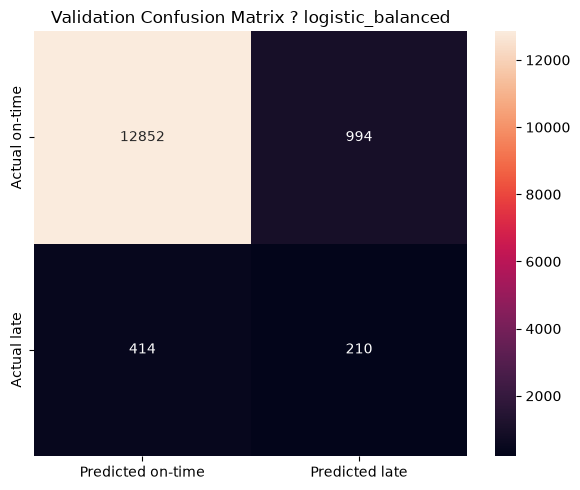

In [10]:
cm = confusion_matrix(
    y_validation,
    threshold_prediction,
)

confusion = pd.DataFrame(
    cm,
    index=["Actual on-time", "Actual late"],
    columns=["Predicted on-time", "Predicted late"],
)

display(confusion)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
)
plt.title(
    f"Validation Confusion Matrix ? {best_model_name}"
)
plt.tight_layout()
plt.show()

## 11. Model-selection contract

Notebook 5 chooses:

- preprocessing rules;
- model family;
- probability threshold.

The test split remains completely untouched.

Notebook 6 will use the frozen decisions from this notebook for one final test evaluation.


In [11]:
best_row = model_results.iloc[0]

print("NOTEBOOK 5 FINAL RESULT")
print(f"Training rows: {len(X_train):,}")
print(f"Validation rows: {len(X_validation):,}")
print(f"Predictor columns before encoding: {X_train.shape[1]}")
print(f"Candidate models evaluated: {len(models)}")
print(f"Best model: {best_model_name}")
print(f"Validation PR-AUC: {best_row['average_precision']:.6f}")
print(f"Validation ROC-AUC: {best_row['roc_auc']:.6f}")
print(f"Selected threshold: {selected_threshold:.6f}")
print(
    "Threshold precision: "
    f"{threshold_metrics.iloc[0]['precision']:.6f}"
)
print(
    "Threshold recall: "
    f"{threshold_metrics.iloc[0]['recall']:.6f}"
)
print(
    "Threshold F1: "
    f"{threshold_metrics.iloc[0]['f1']:.6f}"
)
print("Forbidden feature overlap: 0")
print("Test data opened: NO")
print("Ready for Notebook 6: YES")

NOTEBOOK 5 FINAL RESULT
Training rows: 67,529
Validation rows: 14,470
Predictor columns before encoding: 51
Candidate models evaluated: 3
Best model: logistic_balanced
Validation PR-AUC: 0.133260
Validation ROC-AUC: 0.774280
Selected threshold: 0.708020
Threshold precision: 0.174419
Threshold recall: 0.336538
Threshold F1: 0.229759
Forbidden feature overlap: 0
Test data opened: NO
Ready for Notebook 6: YES
